# SHAP 可解釋性分析 (SHAP Explainability)

學習目標：
- 了解為什麼模型可解釋性很重要
- 學會用 SHAP 解釋隨機森林的預測
- 視覺化每個特徵對預測結果的貢獻

In [1]:
!pip install shap -q

import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. 為什麼需要可解釋性？

黑盒模型的問題：
隨機森林預測「這位選手是菁英」，
但它無法告訴你「為什麼」。

SHAP 解決這個問題：
每個特徵對這次預測貢獻了多少分？
正的 = 推向「菁英」
負的 = 推向「一般」

這跟你 AHP 論文的思路完全一致：
AHP 給每個指標「權重」，
SHAP 給每個特徵「貢獻值」。

In [2]:
# 建立運動員資料（6個特徵）
np.random.seed(42)
n = 300

data = np.column_stack([
    np.random.uniform(5, 30, n),    # 訓練時數
    np.random.uniform(5, 9, n),     # 睡眠時數
    np.random.uniform(18, 35, n),   # 年齡
    np.random.randint(1, 50, n),    # 比賽次數
    np.random.uniform(60, 100, n),  # 體能評分
    np.random.uniform(0, 10, n),    # 技術評分
])

feature_names = ['訓練時數', '睡眠時數', '年齡',
                 '比賽次數', '體能評分', '技術評分']

# 菁英條件
y = ((data[:, 0] > 20) &
     (data[:, 4] > 80) &
     (data[:, 5] > 7)).astype(int)

print(f'菁英：{y.sum()} 位，一般：{(y==0).sum()} 位')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

菁英：13 位，一般：287 位


In [3]:
# 訓練隨機森林
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(f'模型準確率：{rf.score(X_test, y_test):.3f}')

模型準確率：0.950


/tmp/ipykernel_11734/3268179329.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1],
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 30561 (\N{CJK UNIFIED IDEOGRAPH-7761}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 30496 (\N{CJK UNIFIED IDEOGRAPH-7720}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s

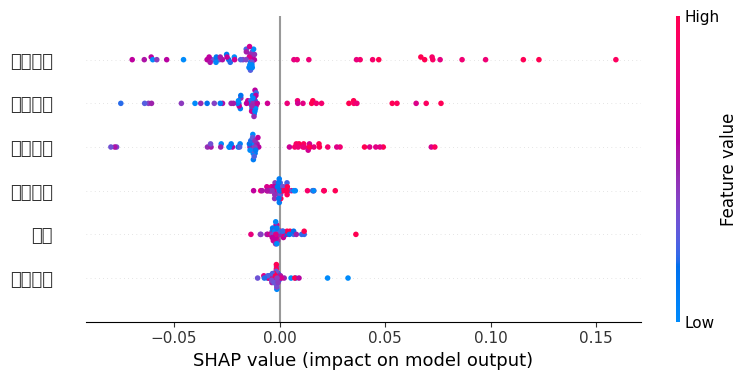

In [4]:
# SHAP 分析
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Summary Plot：所有特徵的整體貢獻
shap.summary_plot(shap_values[:, :, 1],
                  X_test,
                  feature_names=feature_names,
                  show=True)

/tmp/ipykernel_11734/4121783306.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1],
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 30561 (\N{CJK UNIFIED IDEOGRAPH-7761}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 30496 (\N{CJK UNIFIED IDEOGRAPH-7720}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s

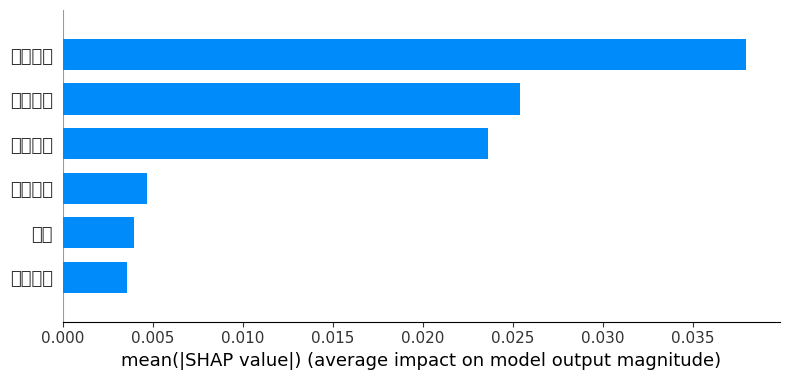

In [5]:
# Bar Plot：特徵重要性（SHAP版本）
shap.summary_plot(shap_values[:, :, 1],
                  X_test,
                  feature_names=feature_names,
                  plot_type='bar',
                  show=True)

第一位測試選手的特徵值：
  訓練時數: 1.37
  睡眠時數: 1.00
  年齡: 0.48
  比賽次數: -0.89
  體能評分: 1.34
  技術評分: 0.35

模型預測：一般


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30561 (\N{CJK UNIFIED IDEOGRAPH-7761}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30496 (\N{CJK UNIFIED IDEOGRAPH-7720}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas

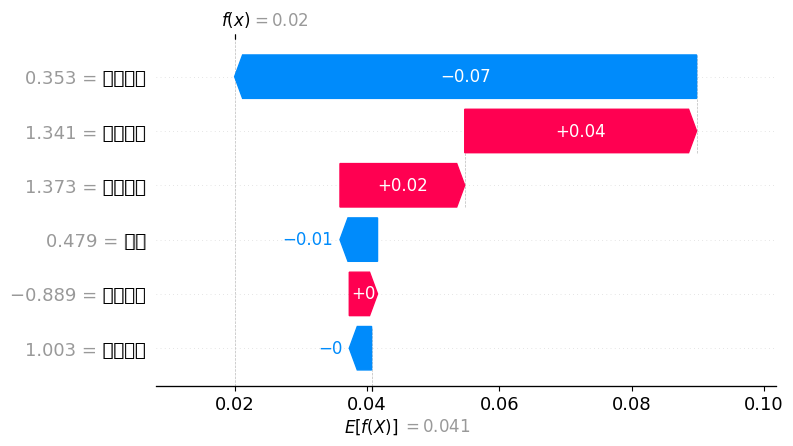

In [6]:
# 解釋單一選手的預測（第一位測試選手）
print('第一位測試選手的特徵值：')
for name, val in zip(feature_names, X_test[0]):
    print(f'  {name}: {val:.2f}')
print(f'\n模型預測：{"菁英" if rf.predict(X_test[0:1])[0]==1 else "一般"}')

# Waterfall Plot：單一預測的詳細解釋
shap_exp = shap.Explanation(
    values=shap_values[0, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test[0],
    feature_names=feature_names)

shap.waterfall_plot(shap_exp, show=True)

## 2. 我的學習筆記

1. 這個主題在做什麼：
   用 SHAP 把黑盒模型變透明，
   讓我們知道每個特徵對每次預測的貢獻。

2. 三種 SHAP 圖的意義：
   - Summary Plot：所有樣本的特徵貢獻分布
   - Bar Plot：平均特徵重要性排名
   - Waterfall Plot：單一樣本的預測解釋

3. 我覺得最難理解的地方：
   Y軸座標文字顯示不出
  

4. 這個跟我研究的連結：
   我的博士研究計畫核心就是：
   用 AHP 取得專家知識作為先驗特徵，
   再用 SHAP 解釋機器學習模型的預測，
   比較「專家判斷」和「資料驅動」的結果是否一致。
   這個 notebook 就是那個分析的實作基礎。